In [10]:
# Instalacja wszystkich wymaganych pakietów
!pip install shap lime xgboost scikit-learn xlrd openpyxl ucimlrepo kagglehub[pandas-datasets]

from sklearn.model_selection import train_test_split, RandomizedSearchCV
from sklearn.metrics import roc_auc_score, f1_score, precision_recall_curve
import urllib.request
import pandas as pd
import numpy as np
import xgboost as xgb
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_auc_score, f1_score
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.preprocessing import LabelEncoder
import shap
import lime
import lime.lime_tabular
from scipy.stats import spearmanr
import warnings
from ucimlrepo import fetch_ucirepo
import kagglehub
from kagglehub import KaggleDatasetAdapter
import seaborn as sns
import matplotlib.pyplot as plt
import statsmodels.api as sm
from statsmodels.stats.outliers_influence import variance_inflation_factor

warnings.filterwarnings('ignore')

In [3]:
datasets = {}

# 1. Baza: Kredyty (Finanse) - via ucimlrepo
default_of_credit_card_clients = fetch_ucirepo(id=350)
X_credit = default_of_credit_card_clients.data.features
y_credit = default_of_credit_card_clients.data.targets.squeeze()

# Mapowanie zmiennych na ich pełne opisy (zgodnie z dokumentacją UCI)
credit_column_mapping = {
    'X1': 'Limit_Balance',
    'X2': 'Gender',
    'X3': 'Education',
    'X4': 'Marital_Status',
    'X5': 'Age',
    'X6': 'Repayment_Status_Sept',
    'X7': 'Repayment_Status_Aug',
    'X8': 'Repayment_Status_Jul',
    'X9': 'Repayment_Status_Jun',
    'X10': 'Repayment_Status_May',
    'X11': 'Repayment_Status_Apr',
    'X12': 'Bill_Amount_Sept',
    'X13': 'Bill_Amount_Aug',
    'X14': 'Bill_Amount_Jul',
    'X15': 'Bill_Amount_Jun',
    'X16': 'Bill_Amount_May',
    'X17': 'Bill_Amount_Apr',
    'X18': 'Previous_Payment_Sept',
    'X19': 'Previous_Payment_Aug',
    'X20': 'Previous_Payment_Jul',
    'X21': 'Previous_Payment_Jun',
    'X22': 'Previous_Payment_May',
    'X23': 'Previous_Payment_Apr'
}

# Zmiana nazw kolumn w zbiorze cech
X_credit = X_credit.rename(columns=credit_column_mapping)

datasets['Credit_Risk'] = {
    'X': X_credit,
    'y': y_credit
}

# 2. Baza: Telco Customer Churn (Telekomunikacja) - via kagglehub
df_telco = kagglehub.load_dataset(
  KaggleDatasetAdapter.PANDAS,
  "blastchar/telco-customer-churn",
  "WA_Fn-UseC_-Telco-Customer-Churn.csv"
)

# Czyszczenie i kodowanie specyficzne dla Telco
df_telco['TotalCharges'] = pd.to_numeric(df_telco['TotalCharges'], errors='coerce')
df_telco = df_telco.dropna()

le = LabelEncoder()
for col in df_telco.select_dtypes(include=['object']).columns:
    if col != 'customerID':
        df_telco[col] = le.fit_transform(df_telco[col])

datasets['Telco_Churn'] = {
    'X': df_telco.drop(columns=['customerID', 'Churn']),
    'y': df_telco['Churn']
}

# 3. Baza: IBM HR Analytics (Zasoby Ludzkie) - via kagglehub
df_hr = kagglehub.load_dataset(
  KaggleDatasetAdapter.PANDAS,
  "pavansubhasht/ibm-hr-analytics-attrition-dataset",
  "WA_Fn-UseC_-HR-Employee-Attrition.csv"
)

# Czyszczenie i kodowanie specyficzne dla HR
for col in df_hr.select_dtypes(include=['object']).columns:
    df_hr[col] = le.fit_transform(df_hr[col])

datasets['HR_Attrition'] = {
    'X': df_hr.drop(columns=['Attrition', 'EmployeeCount', 'EmployeeNumber', 'Over18', 'StandardHours']),
    'y': df_hr['Attrition']
}

print("\nWszystkie trzy bazy danych zostały poprawnie wczytane przez oficjalne API i wstępnie przetworzone.")

Using Colab cache for faster access to the 'telco-customer-churn' dataset.
Using Colab cache for faster access to the 'ibm-hr-analytics-attrition-dataset' dataset.

Wszystkie trzy bazy danych zostały poprawnie wczytane przez oficjalne API i wstępnie przetworzone.


In [6]:

datasets = {}

# 1. Baza: Kredyty (Finanse)
# Tutaj kodowanie zostaje bez zmian, większość danych jest już numeryczna
# Mapowanie zmiennych na ich pełne opisy (zgodnie z dokumentacją UCI)
credit_column_mapping = {
    'X1': 'Limit_Balance',
    'X2': 'Gender',
    'X3': 'Education',
    'X4': 'Marital_Status',
    'X5': 'Age',
    'X6': 'Repayment_Status_Sept',
    'X7': 'Repayment_Status_Aug',
    'X8': 'Repayment_Status_Jul',
    'X9': 'Repayment_Status_Jun',
    'X10': 'Repayment_Status_May',
    'X11': 'Repayment_Status_Apr',
    'X12': 'Bill_Amount_Sept',
    'X13': 'Bill_Amount_Aug',
    'X14': 'Bill_Amount_Jul',
    'X15': 'Bill_Amount_Jun',
    'X16': 'Bill_Amount_May',
    'X17': 'Bill_Amount_Apr',
    'X18': 'Previous_Payment_Sept',
    'X19': 'Previous_Payment_Aug',
    'X20': 'Previous_Payment_Jul',
    'X21': 'Previous_Payment_Jun',
    'X22': 'Previous_Payment_May',
    'X23': 'Previous_Payment_Apr'
}

# Zmiana nazw kolumn w zbiorze cech
X_credit = X_credit.rename(columns=credit_column_mapping)

datasets['Credit_Risk'] = {
    'X': X_credit,
    'y': y_credit
}


# 2. Baza: Telco Customer Churn
df_telco['TotalCharges'] = pd.to_numeric(df_telco['TotalCharges'], errors='coerce')
df_telco = df_telco.dropna()


# Automatyczny podział na cechy binarne i wielokategorialne (nominalne)
# Upewniamy się, że 'Churn' nie jest traktowany jako cecha kategorialna do kodowania
cat_cols_telco = df_telco.select_dtypes(include=['object']).columns.drop('customerID', errors='ignore')

binary_cols_telco = [col for col in cat_cols_telco if df_telco[col].nunique() == 2]
multi_cols_telco = [col for col in cat_cols_telco if df_telco[col].nunique() > 2]

le = LabelEncoder()
# 1. Cechy binarne -> Label Encoder (np. 0 i 1)
for col in binary_cols_telco:
    df_telco[col] = le.fit_transform(df_telco[col])

# 2. Cechy nominalne o wielu kategoriach -> One-Hot Encoding (OHE)
# drop_first=True jest kluczowe dla obliczeń VIF!
df_telco = pd.get_dummies(df_telco, columns=multi_cols_telco, drop_first=True)

# Konwersja boolean (powstałych po get_dummies) na int
df_telco = df_telco.replace({True: 1, False: 0})

datasets['Telco_Churn'] = {
    'X': df_telco.drop(columns=['customerID', 'Churn'], errors='ignore'),
    'y': df_telco['Churn']
}


# 3. Baza: IBM HR Analytics
df_hr = df_hr.drop(columns=['EmployeeCount', 'EmployeeNumber', 'Over18', 'StandardHours'], errors='ignore')

# Zamiana targetu na 0/1 - ta linia jest zbędna i błędna, ponieważ 'Attrition' jest już zakodowany w poprzedniej komórce
# df_hr['Attrition'] = df_hr['Attrition'].map({'Yes': 1, 'No': 0})

cat_cols_hr = df_hr.select_dtypes(include=['object']).columns
binary_cols_hr = [col for col in cat_cols_hr if df_hr[col].nunique() == 2]
multi_cols_hr = [col for col in cat_cols_hr if df_hr[col].nunique() > 2]

# 1. Cechy binarne -> Label Encoder
for col in binary_cols_hr:
    df_hr[col] = le.fit_transform(df_hr[col])

# 2. Cechy nominalne -> OHE
df_hr = pd.get_dummies(df_hr, columns=multi_cols_hr, drop_first=True)
df_hr = df_hr.replace({True: 1, False: 0})

datasets['HR_Attrition'] = {
    'X': df_hr.drop(columns=['Attrition'], errors='ignore'),
    'y': df_hr['Attrition']
}


RAPORT EDA (PEŁNY): Credit_Risk

--- 1. Rozkład zmiennej docelowej (y) ---
   Liczebność  Procent (%)
Y                         
0       23364        77.88
1        6636        22.12


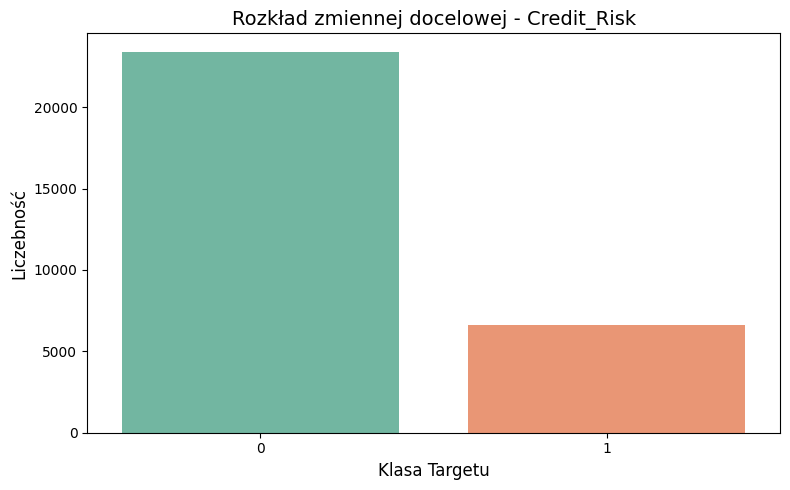


--- 2. Statystyki opisowe (23 cech) ---
Podgląd zmiennych:
<bound method NDFrame.head of                           Min      Max        Średnia   Mediana  \
Age                        21       79      35.485500      34.0   
Bill_Amount_Apr       -339603   961664   38871.760400   17071.0   
Bill_Amount_Aug        -69777   983931   49179.075167   21200.0   
Bill_Amount_Jul       -157264  1664089   47013.154800   20088.5   
Bill_Amount_Jun       -170000   891586   43262.948967   19052.0   
Bill_Amount_May        -81334   927171   40311.400967   18104.5   
Bill_Amount_Sept      -165580   964511   51223.330900   22381.5   
Education                   0        6       1.853133       2.0   
Gender                      1        2       1.603733       2.0   
Limit_Balance           10000  1000000  167484.322667  140000.0   
Marital_Status              0        3       1.551867       2.0   
Previous_Payment_Apr        0   528666    5215.502567    1500.0   
Previous_Payment_Aug        0  1684259 

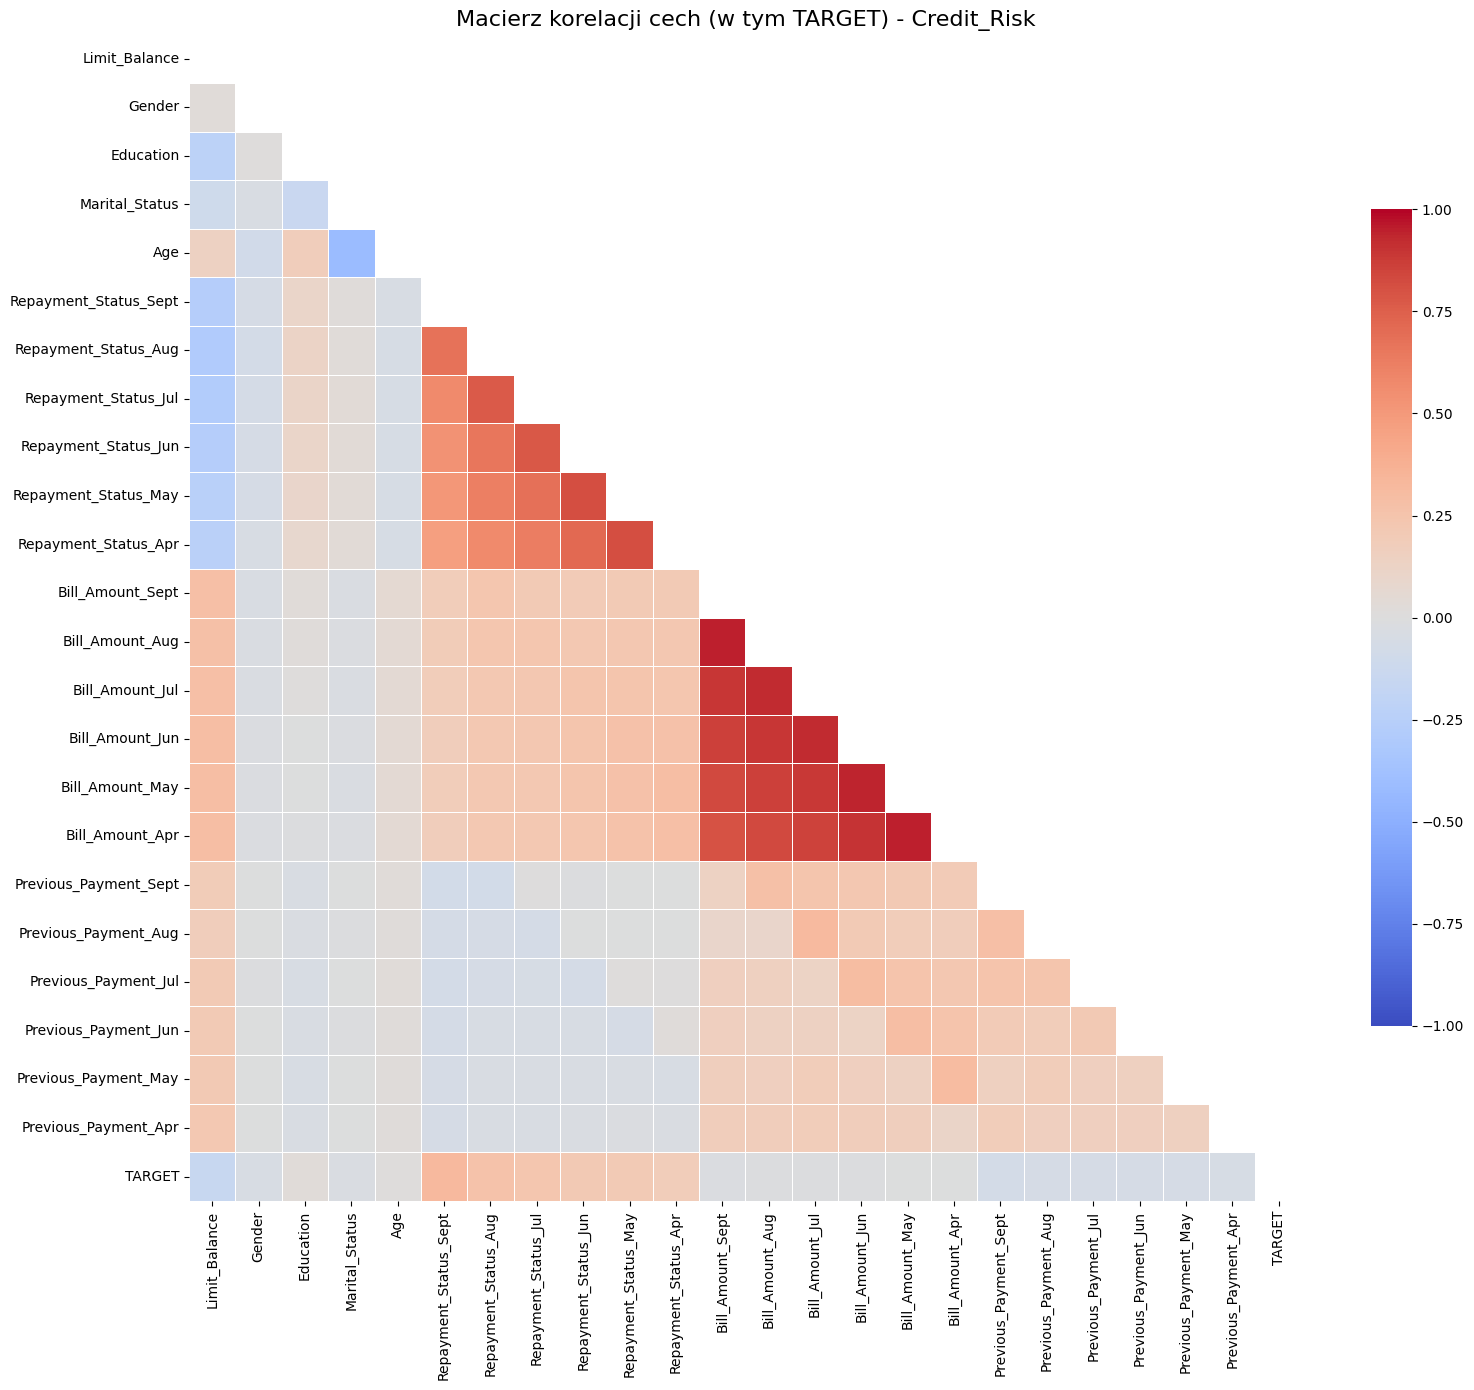


--- 5. Wykresy Gęstości (Zmienna vs Target) ---


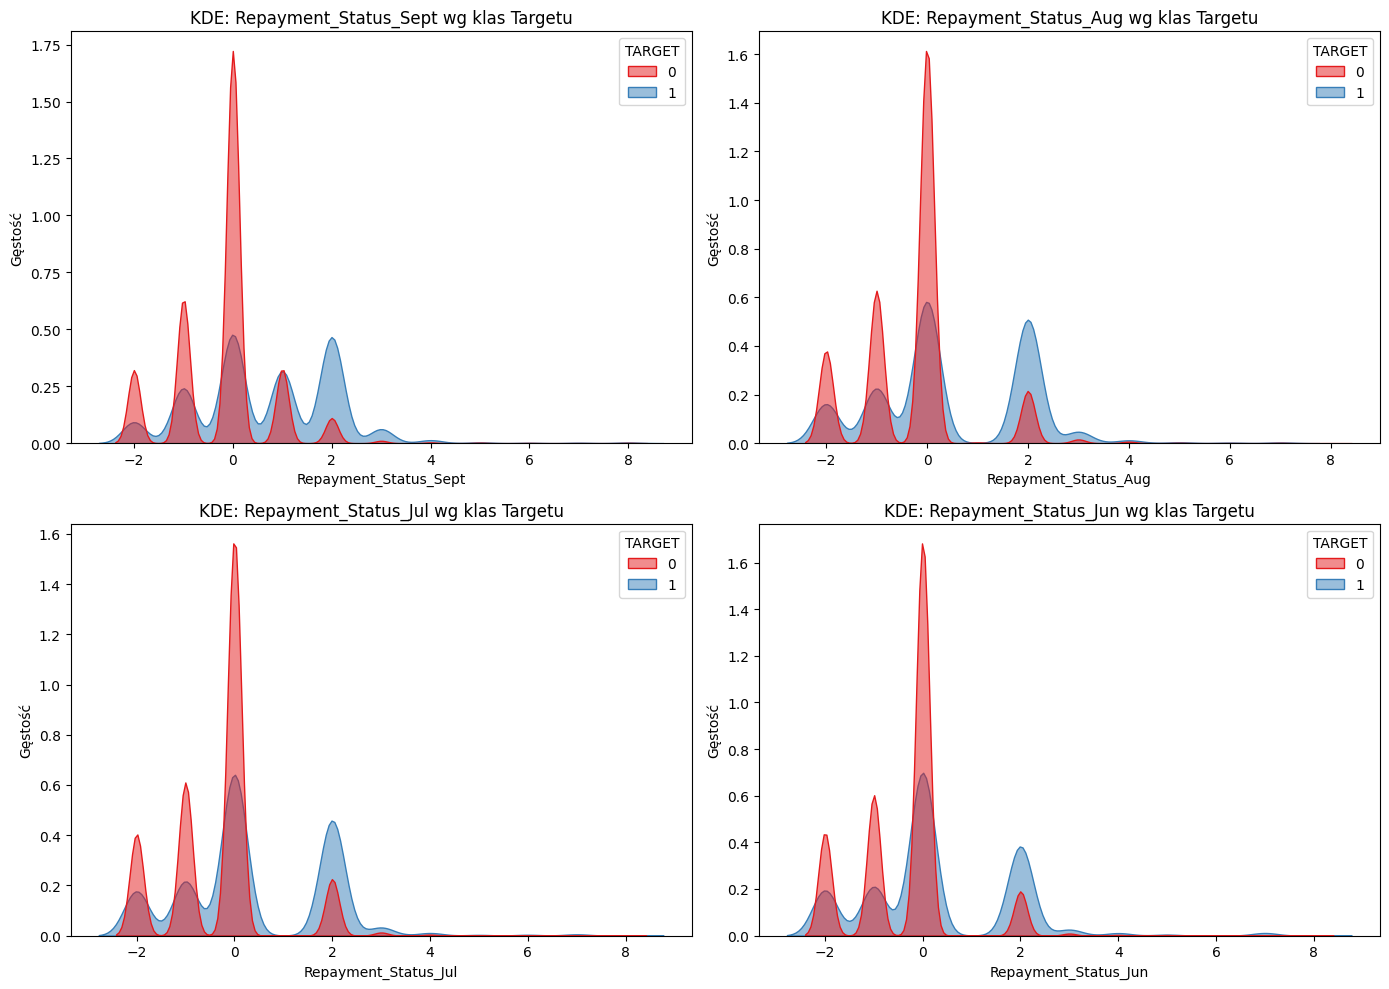


RAPORT EDA (PEŁNY): Telco_Churn

--- 1. Rozkład zmiennej docelowej (y) ---
       Liczebność  Procent (%)
Churn                         
0            5163        73.42
1            1869        26.58


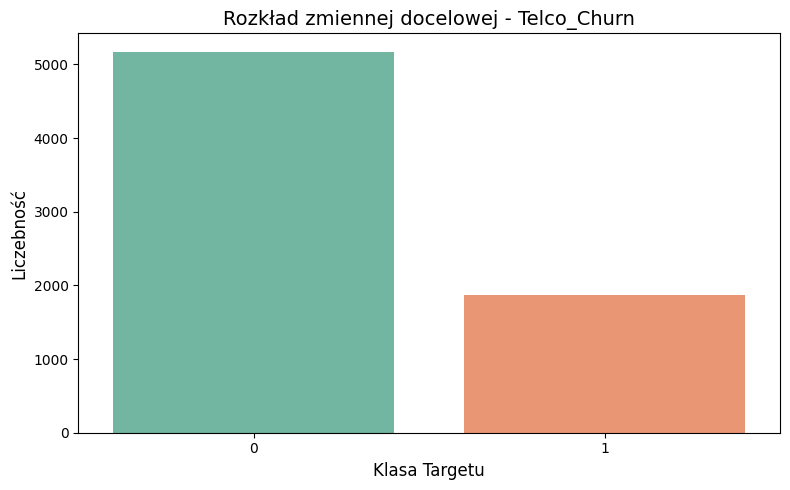


--- 2. Statystyki opisowe (19 cech) ---
Podgląd zmiennych:
<bound method NDFrame.head of                     Min      Max      Średnia   Mediana    Odch. Std  \
Contract           0.00     2.00     0.688567     0.000     0.832934   
Dependents         0.00     1.00     0.298493     0.000     0.457629   
DeviceProtection   0.00     2.00     0.903868     1.000     0.880178   
InternetService    0.00     2.00     0.872582     1.000     0.737271   
MonthlyCharges    18.25   118.75    64.798208    70.350    30.085974   
MultipleLines      0.00     2.00     0.940557     1.000     0.948627   
OnlineBackup       0.00     2.00     0.905859     1.000     0.880394   
OnlineSecurity     0.00     2.00     0.789249     1.000     0.859962   
PaperlessBilling   0.00     1.00     0.592719     1.000     0.491363   
Partner            0.00     1.00     0.482509     0.000     0.499729   
PaymentMethod      0.00     3.00     1.573237     2.000     1.067504   
PhoneService       0.00     1.00     0.903299 

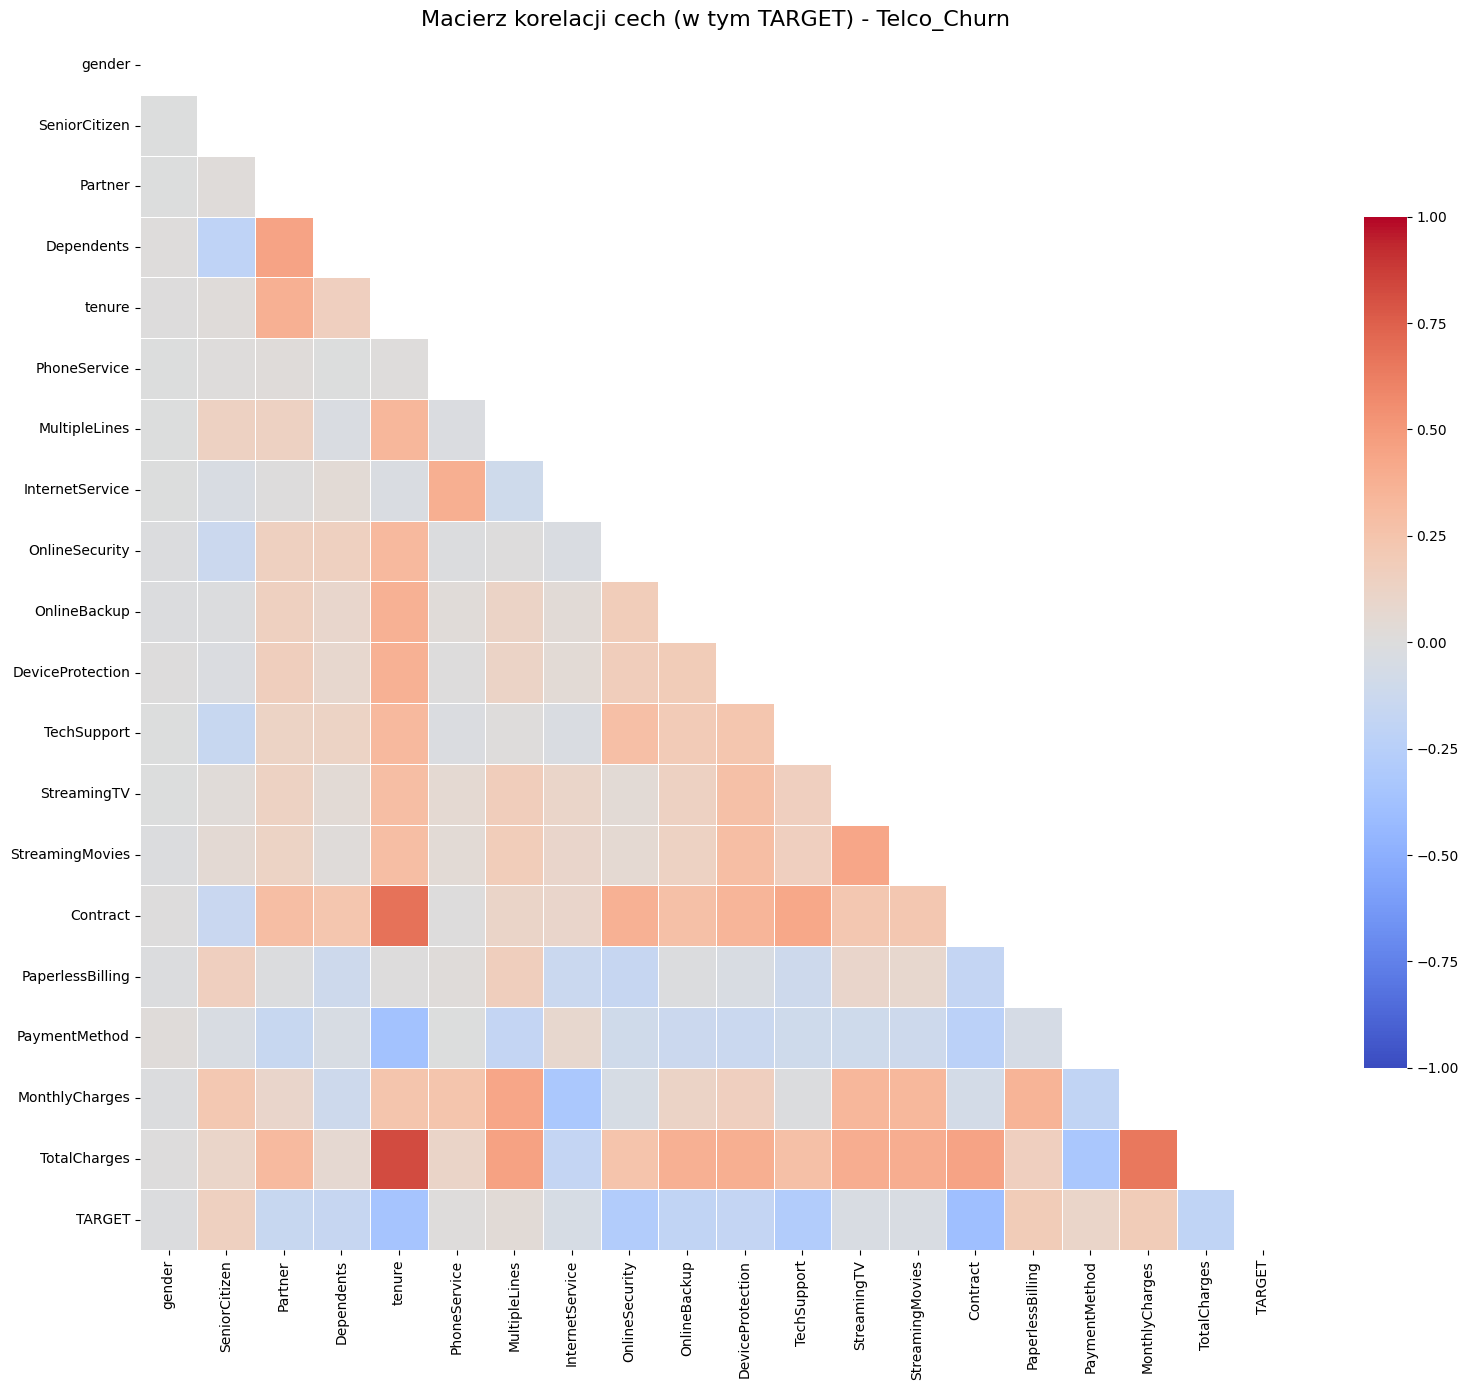


--- 5. Wykresy Gęstości (Zmienna vs Target) ---


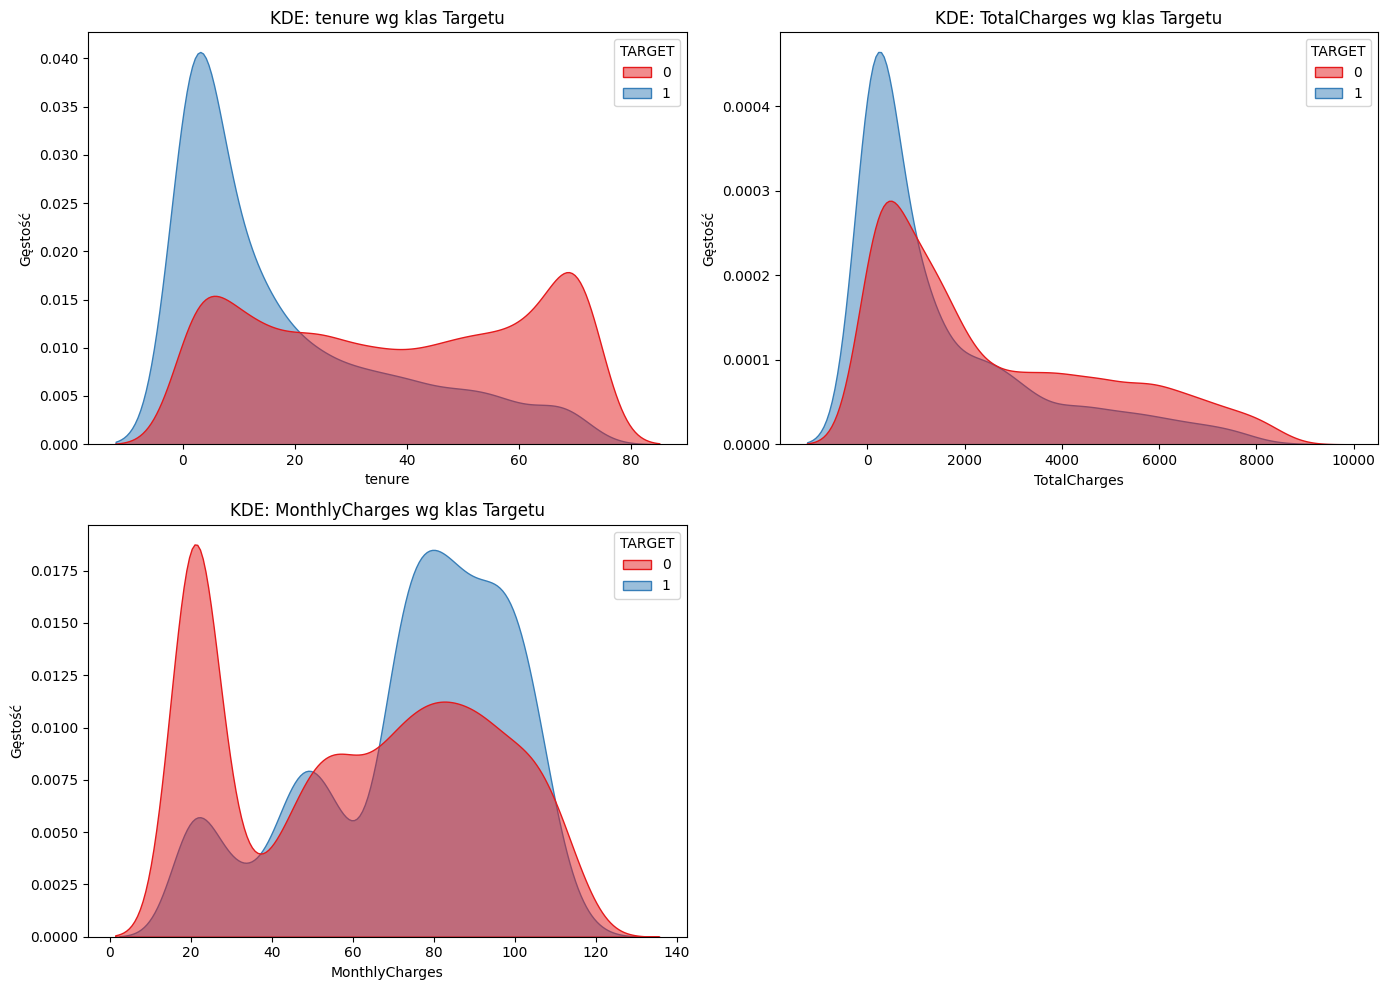


RAPORT EDA (PEŁNY): HR_Attrition

--- 1. Rozkład zmiennej docelowej (y) ---
           Liczebność  Procent (%)
Attrition                         
0                1233        83.88
1                 237        16.12


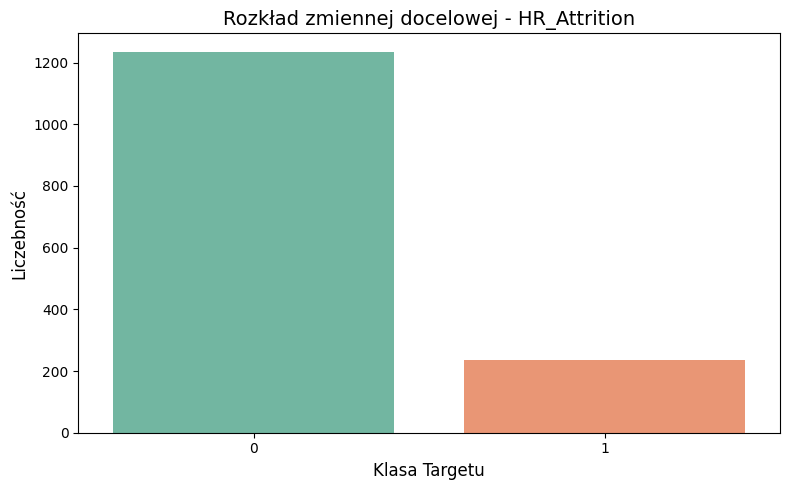


--- 2. Statystyki opisowe (30 cech) ---
Podgląd zmiennych:
<bound method NDFrame.head of                            Min    Max       Średnia  Mediana    Odch. Std  \
Age                         18     60     36.923810     36.0     9.135373   
BusinessTravel               0      2      1.607483      2.0     0.665455   
DailyRate                  102   1499    802.485714    802.0   403.509100   
Department                   0      2      1.260544      1.0     0.527792   
DistanceFromHome             1     29      9.192517      7.0     8.106864   
Education                    1      5      2.912925      3.0     1.024165   
EducationField               0      5      2.247619      2.0     1.331369   
EnvironmentSatisfaction      1      4      2.721769      3.0     1.093082   
Gender                       0      1      0.600000      1.0     0.490065   
HourlyRate                  30    100     65.891156     66.0    20.329428   
JobInvolvement               1      4      2.729932      3.0   

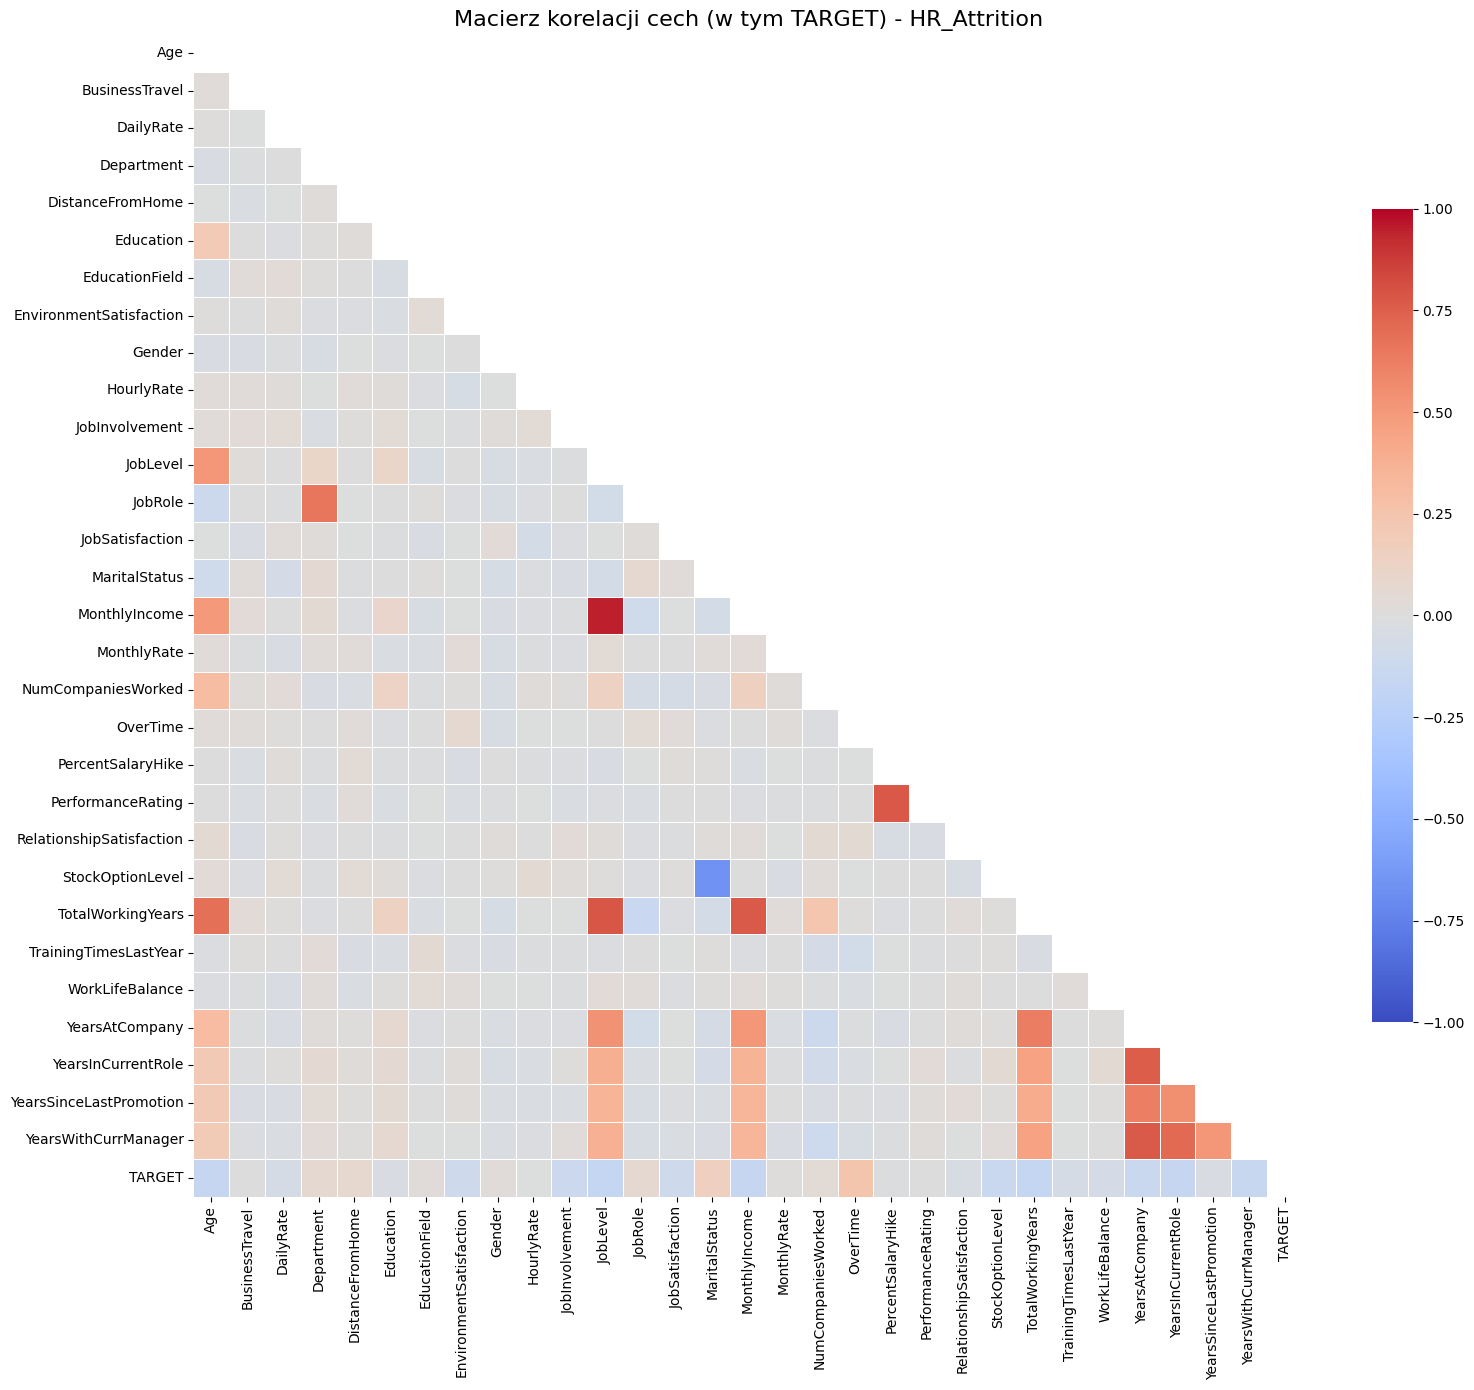


--- 5. Wykresy Gęstości (Zmienna vs Target) ---


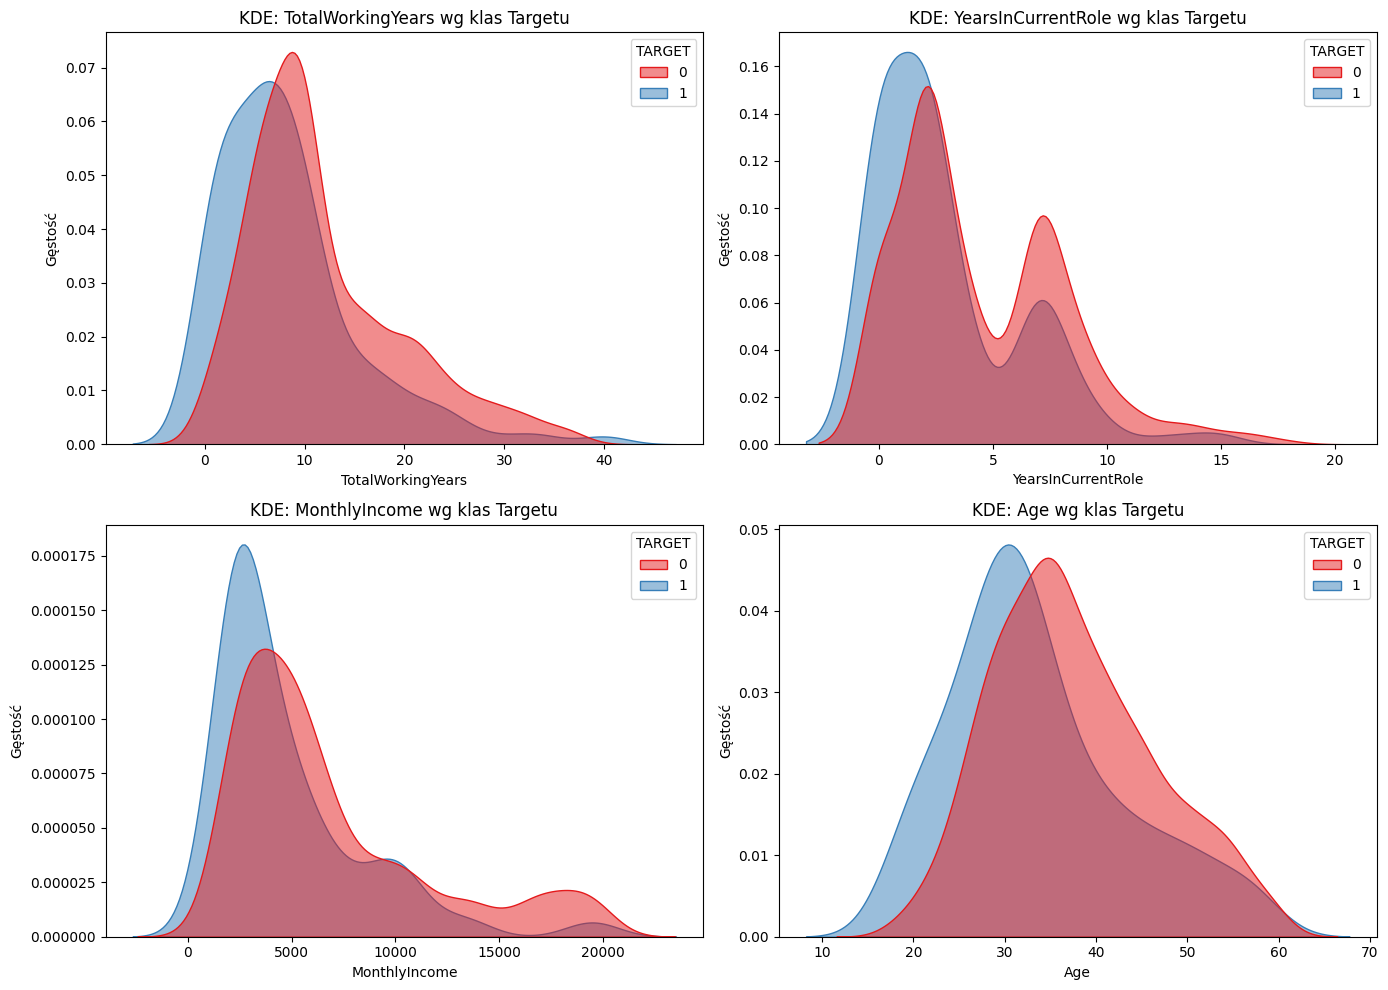

In [8]:
# WERSJA ROBOCZA EDA - Analiza i decyzja dotycząca wyboru najbardziejodpowiednich cech

def generate_full_eda_with_plots(datasets):
    for name, data in datasets.items():
        print(f"\n{'='*80}")
        print(f"RAPORT EDA (PEŁNY): {name}")
        print(f"{'='*80}")

        X = data['X']
        y = data['y']

        # y jest w formacie numerycznym
        y_num = pd.to_numeric(y, errors='coerce')

        # 1. ZMIENNA DOCELOWA (TARGET) - WYKRES
        print("\n--- 1. Rozkład zmiennej docelowej (y) ---")

        # Wyświetlenie tabeli z wartościami
        dist_df = pd.DataFrame({
            'Liczebność': y.value_counts(),
            'Procent (%)': (y.value_counts(normalize=True) * 100).round(2)
        })
        print(dist_df)

        # Generowanie i WYŚWIETLANIE wykresu
        plt.figure(figsize=(8, 5))
        sns.countplot(x=y_num, palette="Set2")
        plt.title(f'Rozkład zmiennej docelowej - {name}', fontsize=14)
        plt.xlabel('Klasa Targetu', fontsize=12)
        plt.ylabel('Liczebność', fontsize=12)
        plt.tight_layout()

        # wykres w notebooku
        plt.show()


        # 2. STATYSTYKI OPISOWE (WSZYSTKIE CECHY)
        num_cols = X.select_dtypes(include=[np.number])

        if not num_cols.empty:
            stats = pd.DataFrame({
                'Min': num_cols.min(),
                'Max': num_cols.max(),
                'Średnia': num_cols.mean(),
                'Mediana': num_cols.median(),
                'Odch. Std': num_cols.std(),
                'Skośność': num_cols.skew(),
                'Kurtoza': num_cols.kurtosis()
            })

            stats = stats.sort_index()
            print(f"\n--- 2. Statystyki opisowe ({len(num_cols.columns)} cech) ---")
            print("Podgląd zmiennych:")
            print(stats.head)

            # Zapis do CSV
            stats.round(4).to_csv(f'statystyki_opisowe_pelne_{name}.csv')
            print(f"[*] Pełne statystyki opisowe zapisano do: statystyki_opisowe_pelne_{name}.csv")


            # 3. ANALIZA VIF
            print("\n--- 3. Analiza Multikolinearności (VIF) ---")
            X_with_const = sm.add_constant(num_cols)
            vif_data = pd.DataFrame()
            vif_data["Cecha"] = X_with_const.columns

            try:
                vif_data["VIF"] = [variance_inflation_factor(X_with_const.values, i)
                                   for i in range(X_with_const.shape[1])]
                vif_data = vif_data[vif_data["Cecha"] != "const"]
                vif_data = vif_data.sort_values(by="VIF", ascending=False).reset_index(drop=True)

                print("Podgląd cech o najwyższym współczynniku VIF:")
                print(vif_data.head)

                vif_data.round(3).to_csv(f'vif_pelny_{name}.csv', index=False)
            except Exception as e:
                print(f"Nie udało się obliczyć VIF: {e}")

            # 4. MACIERZ KORELACJI - WYKRES
            print("\n--- 4. Macierz Korelacji ---")
            df_full = num_cols.copy()
            df_full['TARGET'] = y_num

            corr_matrix = df_full.corr()
            corr_matrix.round(4).to_csv(f'macierz_korelacji_pelna_{name}.csv')

            # Generowanie i WYŚWIETLANIE heatmapy
            plt.figure(figsize=(16, 14)) # Zwiększony rozmiar dla lepszej czytelności wszystkich cech
            mask = np.triu(np.ones_like(corr_matrix, dtype=bool))

            # Jeśli cech jest bardzo dużo (jak po OHE), wyłączamy adnotacje (annot=False),
            # w przeciwnym razie liczby na siebie najdą.
            show_annot = True if len(corr_matrix.columns) < 20 else False

            sns.heatmap(corr_matrix, mask=mask, annot=show_annot, fmt=".2f",
                        cmap='coolwarm', center=0, cbar_kws={"shrink": .7},
                        linewidths=.5, vmin=-1, vmax=1)

            plt.title(f'Macierz korelacji cech (w tym TARGET) - {name}', fontsize=16)
            plt.xticks(rotation=90)
            plt.yticks(rotation=0)
            plt.tight_layout()

            # plt.show() wyświetla macierz w notebooku
            plt.show()


            # 5. WYKRESY KDE

            print("\n--- 5. Wykresy Gęstości (Zmienna vs Target) ---")
            continuous_features = [col for col in num_cols.columns if num_cols[col].nunique() > 5]

            if len(continuous_features) > 0:
                corr_target = df_full[continuous_features + ['TARGET']].corr()['TARGET'].abs().sort_values(ascending=False)
                top_features = corr_target.index[1:5]

                plt.figure(figsize=(14, 10))
                for i, feature in enumerate(top_features, 1):
                    plt.subplot(2, 2, i)
                    sns.kdeplot(data=df_full, x=feature, hue='TARGET', fill=True, common_norm=False, alpha=0.5, palette="Set1")
                    plt.title(f'KDE: {feature} wg klas Targetu')
                    plt.xlabel(feature)
                    plt.ylabel('Gęstość')

                plt.tight_layout()
                plt.show() # Wyświetlenie wykresów KDE
            else:
                print("Brak zmiennych o dużej wariancji (ciągłych) do wygenerowania wykresów KDE.")

# Wywołanie funkcji
generate_full_eda_with_plots(datasets)

Pobieranie bazy: Credit_Risk...
Pobieranie bazy: Telco_Churn...
Using Colab cache for faster access to the 'telco-customer-churn' dataset.
Pobieranie bazy: HR_Attrition...
Using Colab cache for faster access to the 'ibm-hr-analytics-attrition-dataset' dataset.

--- GENEROWANIE WYKRESÓW DLA ZBIORU: Credit_Risk ---


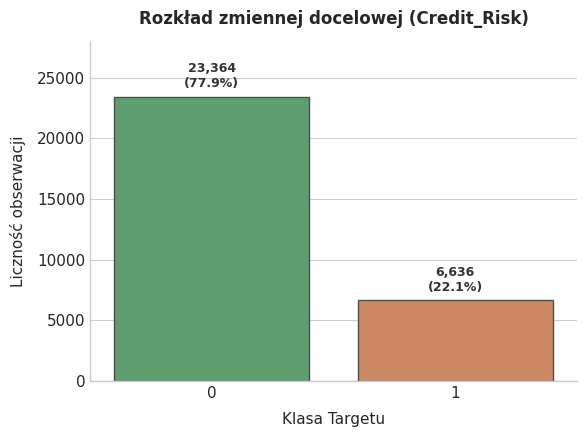

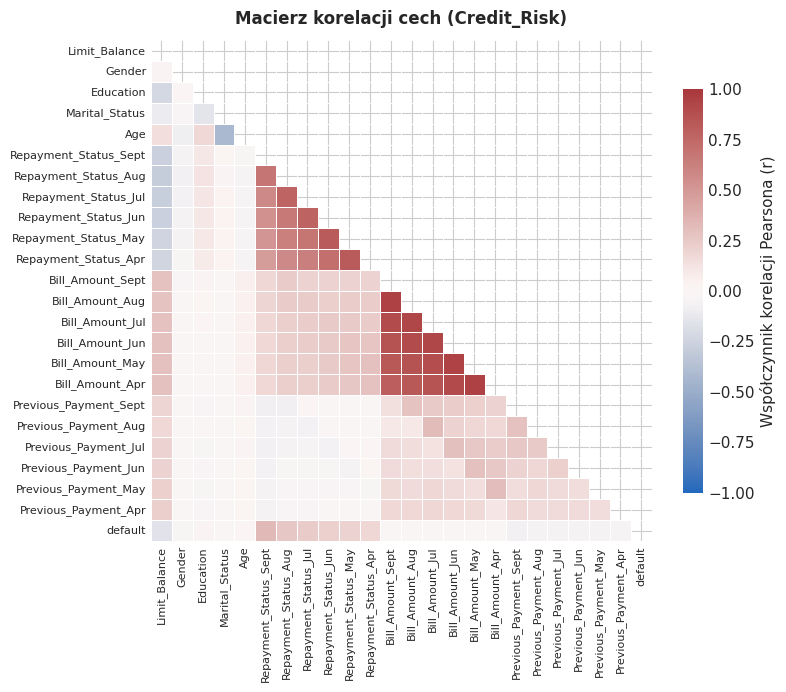

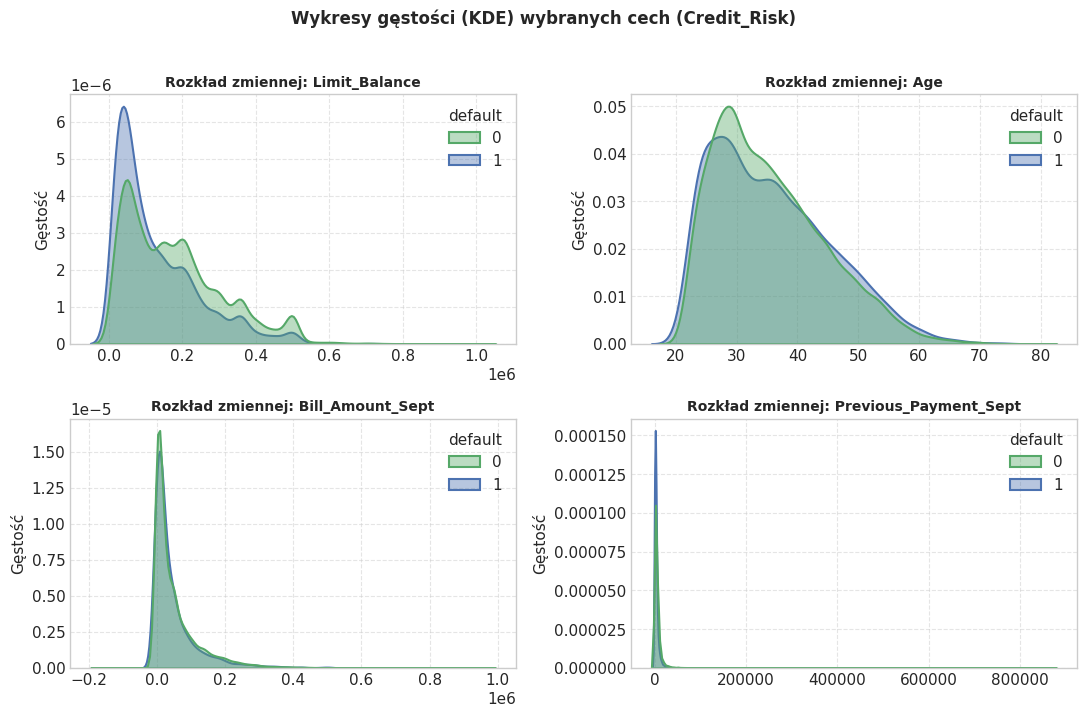


--- GENEROWANIE WYKRESÓW DLA ZBIORU: Telco_Churn ---


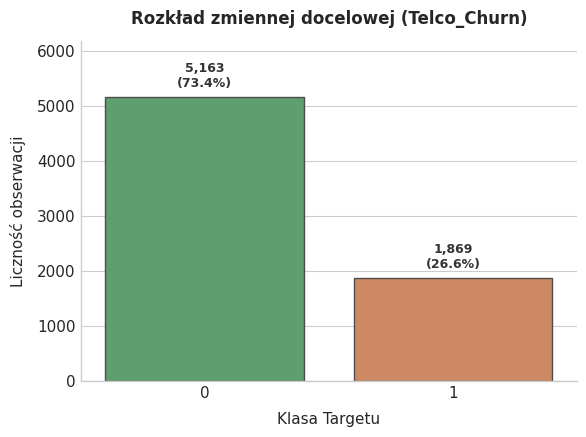

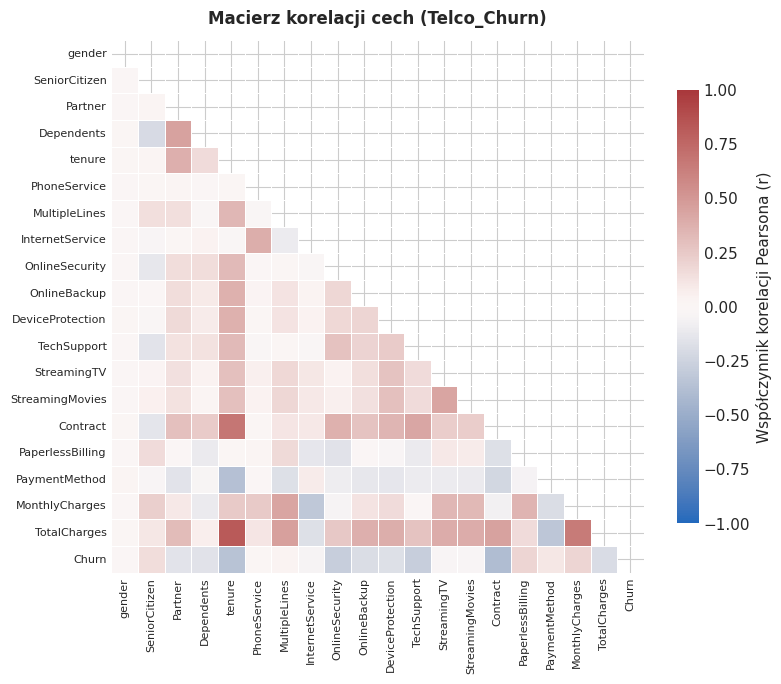

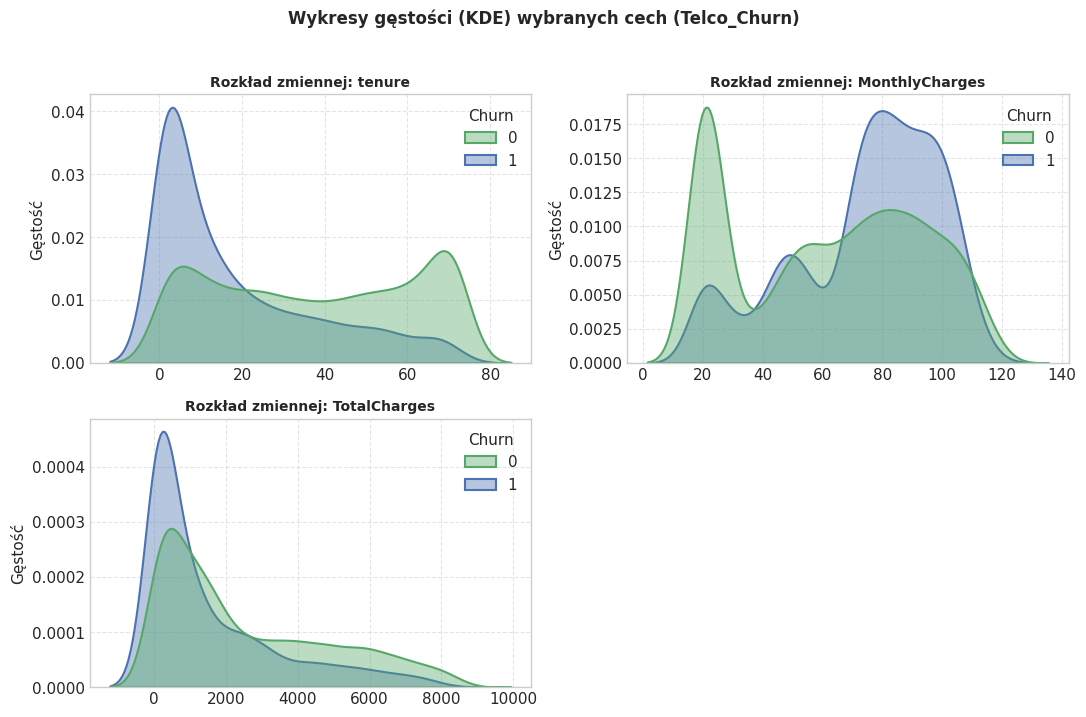


--- GENEROWANIE WYKRESÓW DLA ZBIORU: HR_Attrition ---


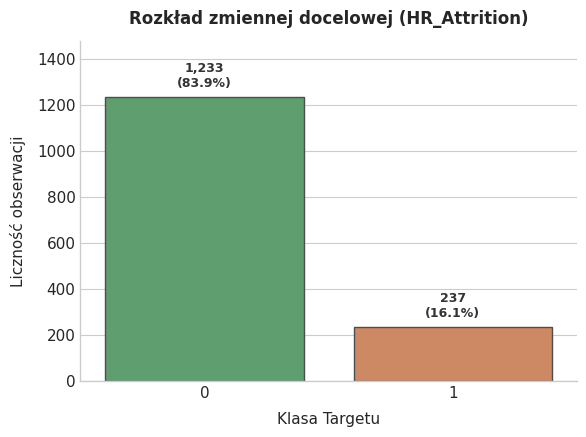

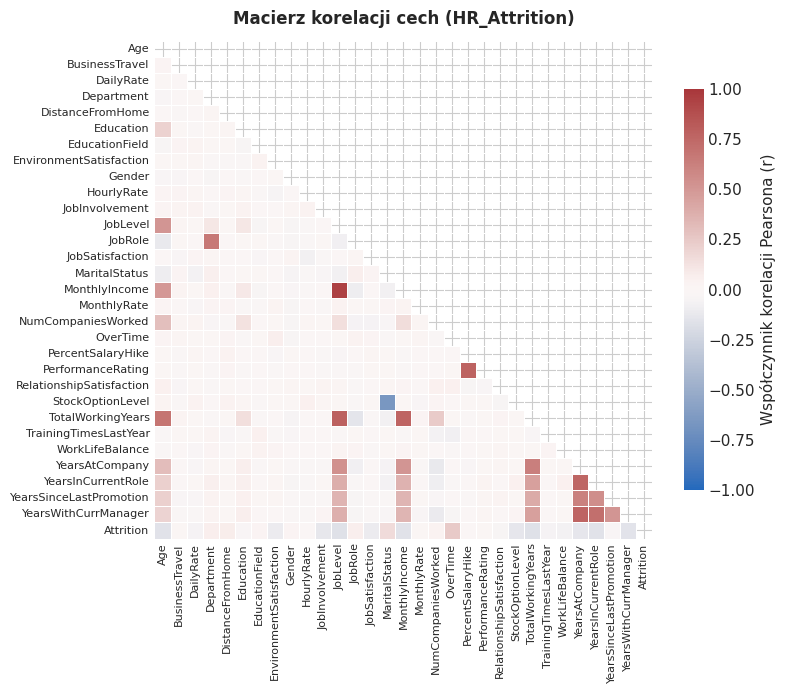

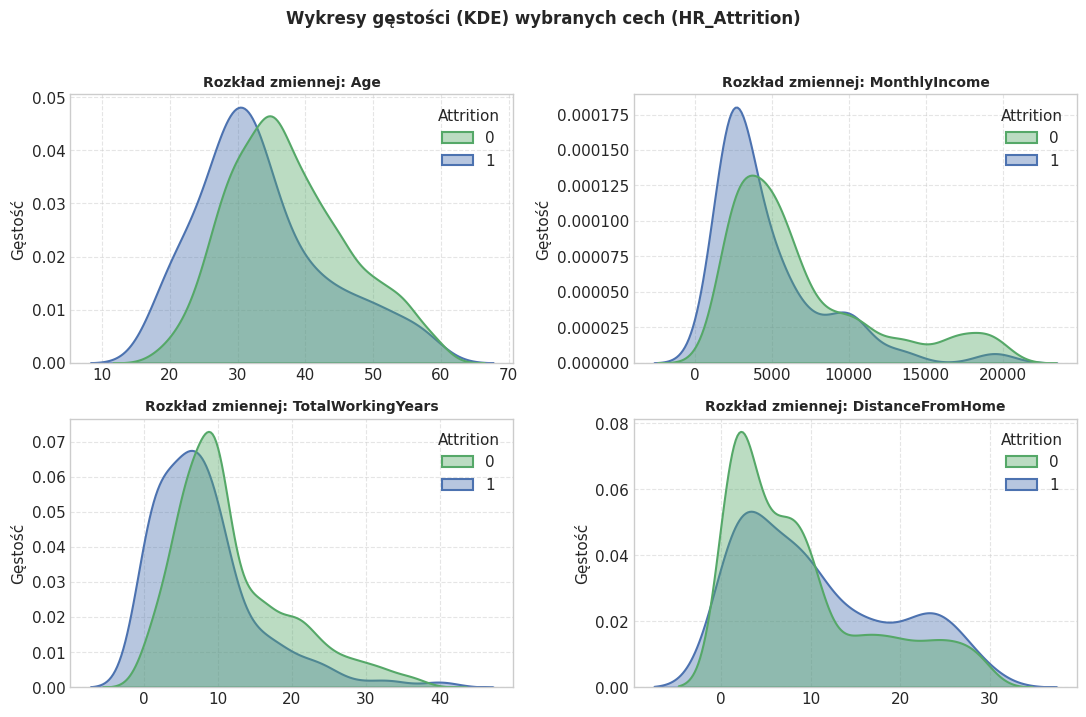

In [9]:


datasets = {}

# --- Pobieranie Credit Risk ---
print("Pobieranie bazy: Credit_Risk...")
credit_data = fetch_ucirepo(id=350)
X_credit = credit_data.data.features
y_credit = credit_data.data.targets.squeeze()

credit_column_mapping = {
    'X1': 'Limit_Balance', 'X2': 'Gender', 'X3': 'Education', 'X4': 'Marital_Status',
    'X5': 'Age', 'X6': 'Repayment_Status_Sept', 'X7': 'Repayment_Status_Aug',
    'X8': 'Repayment_Status_Jul', 'X9': 'Repayment_Status_Jun', 'X10': 'Repayment_Status_May',
    'X11': 'Repayment_Status_Apr', 'X12': 'Bill_Amount_Sept', 'X13': 'Bill_Amount_Aug',
    'X14': 'Bill_Amount_Jul', 'X15': 'Bill_Amount_Jun', 'X16': 'Bill_Amount_May',
    'X17': 'Bill_Amount_Apr', 'X18': 'Previous_Payment_Sept', 'X19': 'Previous_Payment_Aug',
    'X20': 'Previous_Payment_Jul', 'X21': 'Previous_Payment_Jun', 'X22': 'Previous_Payment_May',
    'X23': 'Previous_Payment_Apr'
}
X_credit = X_credit.rename(columns=credit_column_mapping)
datasets['Credit_Risk'] = {'X': X_credit, 'y': y_credit}

# --- Pobieranie Telco Churn ---
print("Pobieranie bazy: Telco_Churn...")
df_telco = kagglehub.load_dataset(KaggleDatasetAdapter.PANDAS, "blastchar/telco-customer-churn", "WA_Fn-UseC_-Telco-Customer-Churn.csv")
df_telco['TotalCharges'] = pd.to_numeric(df_telco['TotalCharges'], errors='coerce')
df_telco = df_telco.dropna()
le = LabelEncoder()
for col in df_telco.select_dtypes(include=['object']).columns:
    if col != 'customerID':
        df_telco[col] = le.fit_transform(df_telco[col])

datasets['Telco_Churn'] = {
    'X': df_telco.drop(columns=['customerID', 'Churn']),
    'y': df_telco['Churn']
}

# --- Pobieranie HR Attrition ---
print("Pobieranie bazy: HR_Attrition...")
df_hr = kagglehub.load_dataset(KaggleDatasetAdapter.PANDAS, "pavansubhasht/ibm-hr-analytics-attrition-dataset", "WA_Fn-UseC_-HR-Employee-Attrition.csv")
for col in df_hr.select_dtypes(include=['object']).columns:
    df_hr[col] = le.fit_transform(df_hr[col])

datasets['HR_Attrition'] = {
    'X': df_hr.drop(columns=['Attrition', 'EmployeeCount', 'EmployeeNumber', 'Over18', 'StandardHours']),
    'y': df_hr['Attrition']
}


# 1. KONFIGURACJA STYLU
plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams['font.family'] = 'DejaVu Sans'
plt.rcParams['font.size'] = 11
plt.rcParams['axes.titlesize'] = 12
plt.rcParams['axes.labelsize'] = 11


# 2. DEFINICJE FUNKCJI WIZUALIZUJĄCYCH (BEZ NUMERÓW W TYTUŁACH)
def plot_target_distribution(df, target_col, dataset_name):
    fig, ax = plt.subplots(figsize=(6, 4.5))
    counts = df[target_col].value_counts().sort_index()
    percentages = df[target_col].value_counts(normalize=True).sort_index() * 100

    bars = sns.barplot(x=counts.index, y=counts.values, palette=['#55a868', '#dd8452'], ax=ax, edgecolor='.3')
    for bar, pct in zip(bars.patches, percentages.values):
        height = bar.get_height()
        ax.annotate(f"{height:,.0f}\n({pct:.1f}%)", xy=(bar.get_x() + bar.get_width() / 2, height),
                    xytext=(0, 5), textcoords="offset points", ha="center", va="bottom", fontsize=9, fontweight="bold", color="#333333")

    ax.set_title(f"Rozkład zmiennej docelowej ({dataset_name})", pad=12, fontweight="bold")
    ax.set_xlabel("Klasa Targetu", labelpad=8)
    ax.set_ylabel("Liczność obserwacji", labelpad=8)
    ax.set_ylim(0, counts.max() * 1.2)
    sns.despine(top=True, right=True)
    plt.tight_layout()
    plt.show()

def plot_correlation_matrix(df, dataset_name):
    fig, ax = plt.subplots(figsize=(8, 7))
    numeric_df = df.select_dtypes(include=[np.number])
    corr = numeric_df.corr()
    mask = np.triu(np.ones_like(corr, dtype=bool))

    sns.heatmap(corr, mask=mask, cmap="vlag", center=0, vmin=-1, vmax=1, annot=False,
                fmt=".2f", square=True, linewidths=.5, cbar_kws={"shrink": .75, "label": "Współczynnik korelacji Pearsona (r)"}, ax=ax)
    ax.set_title(f"Macierz korelacji cech ({dataset_name})", pad=12, fontweight="bold")
    plt.xticks(rotation=90, fontsize=8)
    plt.yticks(rotation=0, fontsize=8)
    plt.tight_layout()
    plt.show()

def plot_density_grid(df, target_col, features, dataset_name):
    n_features = len(features)
    n_cols = 2
    n_rows = (n_features + 1) // 2

    fig, axes = plt.subplots(n_rows, n_cols, figsize=(11, 3.5 * n_rows))
    axes = axes.flatten() if n_features > 1 else [axes]

    for i, feature in enumerate(features):
        ax = axes[i]
        sns.kdeplot(data=df, x=feature, hue=target_col, common_norm=False, fill=True, alpha=0.4, palette=["#55a868", "#4c72b0"], linewidth=1.5, ax=ax)
        ax.set_title(f"Rozkład zmiennej: {feature}", fontsize=10, fontweight="bold")
        ax.set_xlabel("")
        ax.set_ylabel("Gęstość")
        ax.grid(True, linestyle="--", alpha=0.5)

    for j in range(i + 1, len(axes)):
        fig.delaxes(axes[j])

    fig.suptitle(f"Wykresy gęstości (KDE) wybranych cech ({dataset_name})", fontsize=12, fontweight="bold", y=1.02)
    plt.tight_layout()
    plt.show()


# 3. WYWOŁANIE WYKRESÓW
print("\n--- Credit_Risk ---")
df_credit_full = datasets['Credit_Risk']['X'].copy()
df_credit_full['default'] = datasets['Credit_Risk']['y']
plot_target_distribution(df_credit_full, 'default', 'Credit_Risk')
plot_correlation_matrix(df_credit_full, 'Credit_Risk')
plot_density_grid(df_credit_full, 'default', ['Limit_Balance', 'Age', 'Bill_Amount_Sept', 'Previous_Payment_Sept'], 'Credit_Risk')

print("\n--- Telco_Churn ---")
df_telco_full = datasets['Telco_Churn']['X'].copy()
df_telco_full['Churn'] = datasets['Telco_Churn']['y']
plot_target_distribution(df_telco_full, 'Churn', 'Telco_Churn')
plot_correlation_matrix(df_telco_full, 'Telco_Churn')
plot_density_grid(df_telco_full, 'Churn', ['tenure', 'MonthlyCharges', 'TotalCharges'], 'Telco_Churn')

print("\n--- HR_Attrition ---")
df_hr_full = datasets['HR_Attrition']['X'].copy()
df_hr_full['Attrition'] = datasets['HR_Attrition']['y']
plot_target_distribution(df_hr_full, 'Attrition', 'HR_Attrition')
plot_correlation_matrix(df_hr_full, 'HR_Attrition')
plot_density_grid(df_hr_full, 'Attrition', ['Age', 'MonthlyIncome', 'TotalWorkingYears', 'DistanceFromHome'], 'HR_Attrition')

In [11]:


results = {}

for name, data in datasets.items():
    print(f"\n{'='*50}\nROZPOCZYNAM ANALIZĘ DLA ZBIORU: {name}\n{'='*50}")

    # --- PRZYGOTOWANIE ZBIORÓW TRENINGOWYCH I TESTOWYCH ---
    X_train, X_test, y_train, y_test = train_test_split(data['X'], data['y'], test_size=0.2, random_state=42)
    scaler = StandardScaler()
    X_train_scaled = pd.DataFrame(scaler.fit_transform(X_train), columns=data['X'].columns)
    X_test_scaled = pd.DataFrame(scaler.transform(X_test), columns=data['X'].columns)

    # ETAP 1: Benchmarking (Regresja vs Zoptymalizowany XGBoost)
    lr_model = LogisticRegression(max_iter=1000, random_state=42)
    lr_model.fit(X_train_scaled, y_train)
    lr_preds = lr_model.predict_proba(X_test_scaled)[:, 1]
    lr_preds_class = lr_model.predict(X_test_scaled)

    # Optymalizacja hiperparametrów XGBoost (RandomizedSearchCV)
    xgb_base = xgb.XGBClassifier(use_label_encoder=False, eval_metric='logloss', random_state=42)
    param_dist = {
        'max_depth': [3, 4, 5, 6],
        'learning_rate': [0.01, 0.05, 0.1, 0.2],
        'subsample': [0.7, 0.8, 0.9, 1.0]
    }
    xgb_search = RandomizedSearchCV(xgb_base, param_distributions=param_dist, n_iter=10,
                                    scoring='roc_auc', cv=3, random_state=42, n_jobs=-1)
    xgb_search.fit(X_train_scaled, y_train)
    xgb_best = xgb_search.best_estimator_

    # Predykcje i kalibracja progu odcięcia dla F1-score na zbiorze treningowym
    xgb_preds = xgb_best.predict_proba(X_test_scaled)[:, 1]
    xgb_train_preds = xgb_best.predict_proba(X_train_scaled)[:, 1]

    precisions, recalls, thresholds = precision_recall_curve(y_train, xgb_train_preds)
    f1_scores = 2 * (precisions * recalls) / (precisions + recalls + 1e-10)
    best_threshold = thresholds[np.argmax(f1_scores)]
    xgb_preds_class = (xgb_preds >= best_threshold).astype(int)

    auc_lr = roc_auc_score(y_test, lr_preds)
    f1_lr = f1_score(y_test, lr_preds_class)
    auc_xgb = roc_auc_score(y_test, xgb_preds)
    f1_xgb = f1_score(y_test, xgb_preds_class)

    print(f"[H1] Skuteczność - {name}:")
    print(f"  Regresja: AUC = {auc_lr:.3f}, F1 = {f1_lr:.3f}")
    print(f"  XGBoost : AUC = {auc_xgb:.3f}, F1 = {f1_xgb:.3f} (optymalny próg: {best_threshold:.2f})")

    # Inicjalizacja Explainerów
    explainer_shap = shap.TreeExplainer(xgb_best)

    # ETAP 2: Odporność na zaszumienie Strict Local-to-Local (SHAP vs LIME)
    np.random.seed(42)
    noise = np.random.normal(0, 0.1, X_test_scaled.shape)
    X_test_noisy = X_test_scaled + noise

    explainer_lime = lime.lime_tabular.LimeTabularExplainer(
        X_train_scaled.values, feature_names=data['X'].columns, class_names=['0', '1'], mode='classification'
    )

    num_cols = len(data['X'].columns)
    shap_corrs, lime_corrs = [], []

    # Test na 50 obserwacjach - perspektywa ściśle lokalna
    for i in range(50):
        # -- Stabilność LIME --
        exp_orig = explainer_lime.explain_instance(X_test_scaled.iloc[i].values, xgb_best.predict_proba, num_features=num_cols)
        exp_noisy = explainer_lime.explain_instance(X_test_noisy.iloc[i].values, xgb_best.predict_proba, num_features=num_cols)

        d_orig = dict(exp_orig.local_exp[1])
        d_noisy = dict(exp_noisy.local_exp[1])

        ranks_orig_lime = [d_orig.get(idx, 0) for idx in range(num_cols)]
        ranks_noisy_lime = [d_noisy.get(idx, 0) for idx in range(num_cols)]
        corr_lime, _ = spearmanr(np.abs(ranks_orig_lime), np.abs(ranks_noisy_lime))
        if not np.isnan(corr_lime): lime_corrs.append(corr_lime)

        # -- Stabilność SHAP (na tej samej instancji co LIME) --
        shap_orig = explainer_shap.shap_values(X_test_scaled.iloc[i:i+1])[0]
        shap_noisy = explainer_shap.shap_values(X_test_noisy.iloc[i:i+1])[0]
        corr_shap, _ = spearmanr(np.abs(shap_orig), np.abs(shap_noisy))
        if not np.isnan(corr_shap): shap_corrs.append(corr_shap)

    print(f"[H2] Średnia Stabilność Lokalna (Spearman) - {name}:")
    print(f"  Korelacja SHAP: {np.mean(shap_corrs):.3f}")
    print(f"  Korelacja LIME: {np.mean(lime_corrs):.3f}")

    # ETAP 3: Demaskowanie wycieku danych (Proxy Target Leakage)
    X_train_leak, X_test_leak = X_train_scaled.copy(), X_test_scaled.copy()

    # Wybieram pierwszą kolumnę z brzegu - realistyczny wyciek pośredni
    leak_col = X_train_scaled.columns[0]
    X_train_leak[leak_col] = X_train_scaled[leak_col] * 0.5 + y_train.values * 0.5
    X_test_leak[leak_col] = X_test_scaled[leak_col] * 0.5 + y_test.values * 0.5

    xgb_leak = xgb.XGBClassifier(use_label_encoder=False, eval_metric='logloss', random_state=42)
    xgb_leak.fit(X_train_leak, y_train)
    auc_leak = roc_auc_score(y_test, xgb_leak.predict_proba(X_test_leak)[:, 1])

    explainer_leak = shap.TreeExplainer(xgb_leak)
    shap_values_leak = explainer_leak.shap_values(X_test_leak)

    # Wkład zmanipulowanej zmiennej
    leak_importance = np.abs(shap_values_leak).mean(axis=0)
    leak_idx = list(X_train_leak.columns).index(leak_col)
    leak_share = leak_importance[leak_idx] / np.sum(leak_importance)

    print(f"[H3] Demaskowanie Proxy Leakage ({leak_col}) - {name}:")
    print(f"  Fałszywy AUC (z ukrytym wyciekiem) : {auc_leak:.3f}")
    print(f"  Wpływ zmiennej (SHAP) na decyzję : {leak_share*100:.1f}%\n")


ROZPOCZYNAM ANALIZĘ DLA ZBIORU: Credit_Risk
[H1] Skuteczność - Credit_Risk:
  Regresja: AUC = 0.727, F1 = 0.353
  XGBoost : AUC = 0.784, F1 = 0.542 (optymalny próg: 0.27)
[H2] Średnia Stabilność Lokalna (Spearman) - Credit_Risk:
  Korelacja SHAP: 0.715
  Korelacja LIME: 0.539
[H3] Demaskowanie Proxy Leakage (Limit_Balance) - Credit_Risk:
  Fałszywy AUC (z ukrytym wyciekiem) : 1.000
  Wpływ zmiennej (SHAP) na decyzję : 76.6%


ROZPOCZYNAM ANALIZĘ DLA ZBIORU: Telco_Churn
[H1] Skuteczność - Telco_Churn:
  Regresja: AUC = 0.831, F1 = 0.551
  XGBoost : AUC = 0.833, F1 = 0.606 (optymalny próg: 0.37)
[H2] Średnia Stabilność Lokalna (Spearman) - Telco_Churn:
  Korelacja SHAP: 0.927
  Korelacja LIME: 0.762
[H3] Demaskowanie Proxy Leakage (gender) - Telco_Churn:
  Fałszywy AUC (z ukrytym wyciekiem) : 1.000
  Wpływ zmiennej (SHAP) na decyzję : 83.5%


ROZPOCZYNAM ANALIZĘ DLA ZBIORU: HR_Attrition
[H1] Skuteczność - HR_Attrition:
  Regresja: AUC = 0.771, F1 = 0.475
  XGBoost : AUC = 0.767, F1 = 0.